In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yasserh/advertising-sales-dataset/Advertising Budget and Sales.csv


In [24]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/advertising-sales-dataset/Advertising Budget and Sales.csv', index_col = 0)
df.head(4)

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5


In [25]:
df.isnull().sum()

TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

In [26]:
df.shape
df.skew()

TV Ad Budget ($)          -0.069853
Radio Ad Budget ($)        0.094175
Newspaper Ad Budget ($)    0.894720
Sales ($)                  0.407571
dtype: float64

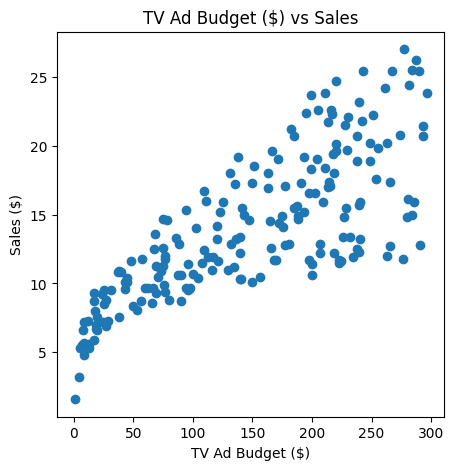

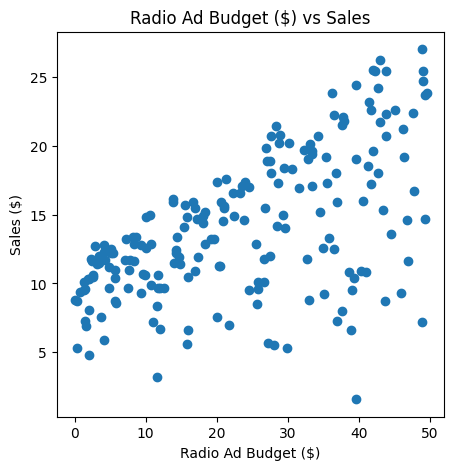

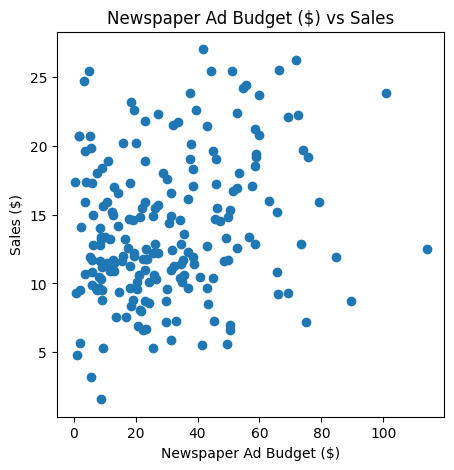

In [27]:
import matplotlib.pyplot as plt
# fig = figure(figsize(15,5))

for col in df.columns:
    if col != 'Sales ($)':
    
        plt.figure(figsize=(5,5))
        plt.scatter(df[col], df['Sales ($)'])
        plt.xlabel(f'{col}')
        plt.ylabel (f'{'Sales ($)'}')
        plt.title(f'{col} vs Sales')
        
    plt.show()     


In [28]:
features =  ['TV Ad Budget ($)','Radio Ad Budget ($)','Newspaper Ad Budget ($)' ]
target = ['Sales ($)']

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(df[features],df[target],test_size = 0.2, random_state =42)

print(x_train.shape)
print(x_test.shape)


(160, 3)
(40, 3)


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

pipeline = Pipeline( [
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
    
])


In [30]:

pipeline.fit(x_train,y_train)
y_pred = pipeline.predict(x_test)
r2score = r2_score(y_test,y_pred)
print(r2score)

0.8994380241009119


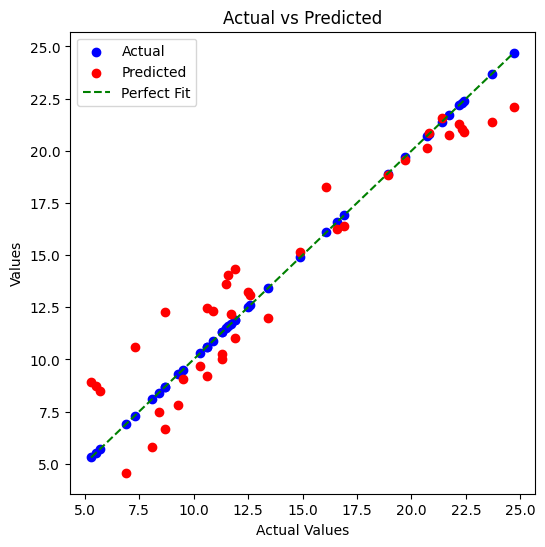

In [31]:
#PLotting to see how test and pred looks like 

plt.figure(figsize=(6,6))

# Actual values (blue)
plt.scatter(y_test, y_test, color='blue', label='Actual')

# Predicted values (red)
plt.scatter(y_test, y_pred, color='red', label='Predicted')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='green', linestyle='--', label='Perfect Fit'
)

plt.xlabel('Actual Values')
plt.ylabel('Values')
plt.title('Actual vs Predicted')
plt.legend()

In [35]:
import pickle as pc
pc.dump(pipeline,open('Avertising_model_sales.pkl','wb'))